# Breast Cancer Detection - Logistic Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

## Load Data

The preprocessed and standardized data is loaded from `data/processedData/`. These CSVs were generated by the data preprocessor notebook, which applied standardization ($z = \frac{x - \mu}{\sigma}$) and an 80/20 stratified split (455 training, 114 test samples).

In [3]:
X_train = pd.read_csv("../data/processedData/X_train_scaled.csv", index_col=0).values
Y_train = pd.read_csv("../data/processedData/Y_train.csv", index_col=0).values.ravel()

X_test = pd.read_csv("../data/processedData/X_test_scaled.csv", index_col=0).values
Y_test = pd.read_csv("../data/processedData/Y_test.csv", index_col=0).values.ravel()

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}, Features: {X_train.shape[1]}")

Training samples: 455, Test samples: 114, Features: 30


## Train Logistic Regression Model

**Logistic Regression** is a linear classifier that models the probability of malignancy as:

$$\hat{y} = \sigma(w \cdot x + b), \quad \sigma(z) = \frac{1}{1 + e^{-z}}$$

It serves as a strong interpretable baseline - simpler than SVM and far less compute-heavy than a neural network. `max_iter=1000` is required because the default (100) does not converge on 30 standardized features.

In [4]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, Y_train)
print("Model trained.")

Model trained.


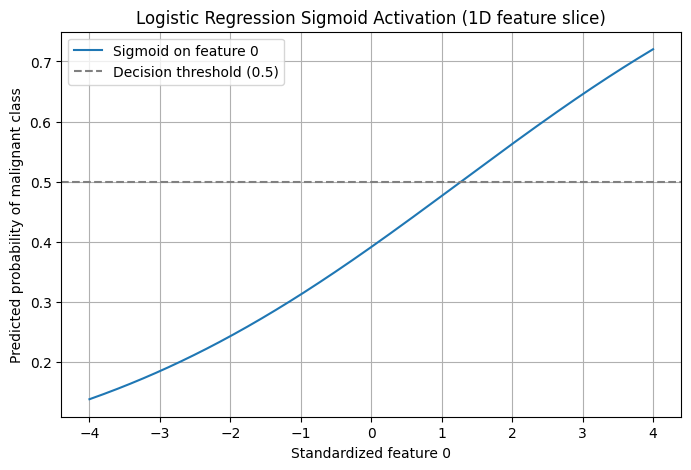

In [ ]:
# True sigmoid mapping from logit to probability for the trained model
logits = model.decision_function(X_test)
probs = model.predict_proba(X_test)[:, 1]

x_sort = np.linspace(logits.min() - 1, logits.max() + 1, 300)
theta_prob = 1 / (1 + np.exp(-x_sort))

plt.figure(figsize=(8, 5))
plt.scatter(logits, probs, alpha=0.6, s=40, label="Test samples (probability)")
plt.plot(x_sort, theta_prob, color="red", linewidth=2, label="Sigmoid function $\sigma(z)=1/(1+e^{-z})$")
plt.axvline(0, color="gray", linestyle="--", label="Logit = 0 (threshold probability 0.5)")
plt.title("Logistic Regression Sigmoid: decision function logits to predicted probability")
plt.xlabel("Logit (w·x + b)")
plt.ylabel("Predicted probability of malignant class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Test accuracy: {accuracy_score(Y_test, model.predict(X_test)):.4f}")

## Evaluate on Test Set

Predictions are made on the held-out test set. **Recall for the malignant class (1) is the most critical metric** - a false negative (missed cancer) is more dangerous than a false positive.

In [11]:
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, predictions))
print()
print(classification_report(Y_test, predictions, target_names=["Benign (0)", "Malignant (1)"]))

Accuracy: 0.9649122807017544

               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



### Confusion Matrix

Rows = actual class, columns = predicted class. The bottom-left cell (actual Malignant, predicted Benign) is the **false negative** count - the most important number to minimize in cancer detection.

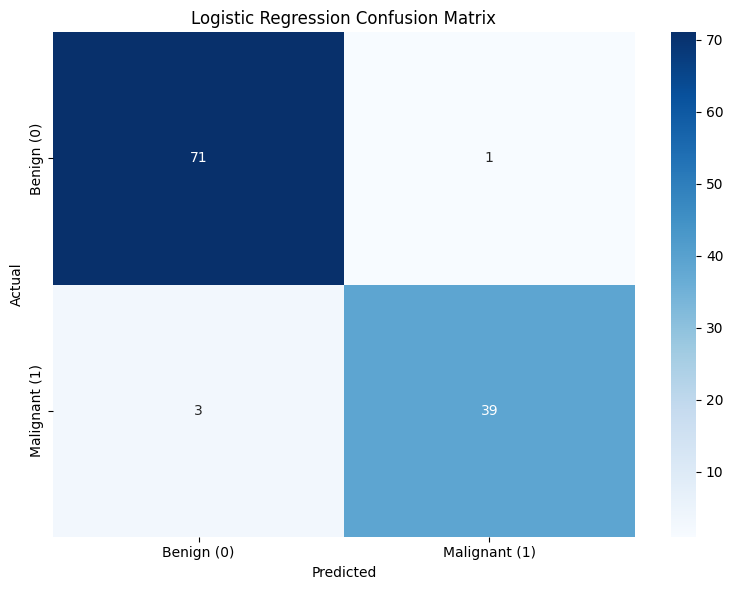

In [6]:
cm = confusion_matrix(Y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign (0)", "Malignant (1)"],
    yticklabels=["Benign (0)", "Malignant (1)"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## Decision Boundary (2D PCA)

PCA reduces the 30 features to 2 principal components for visualization. A second Logistic Regression model is trained in this 2D space to draw the decision boundary.

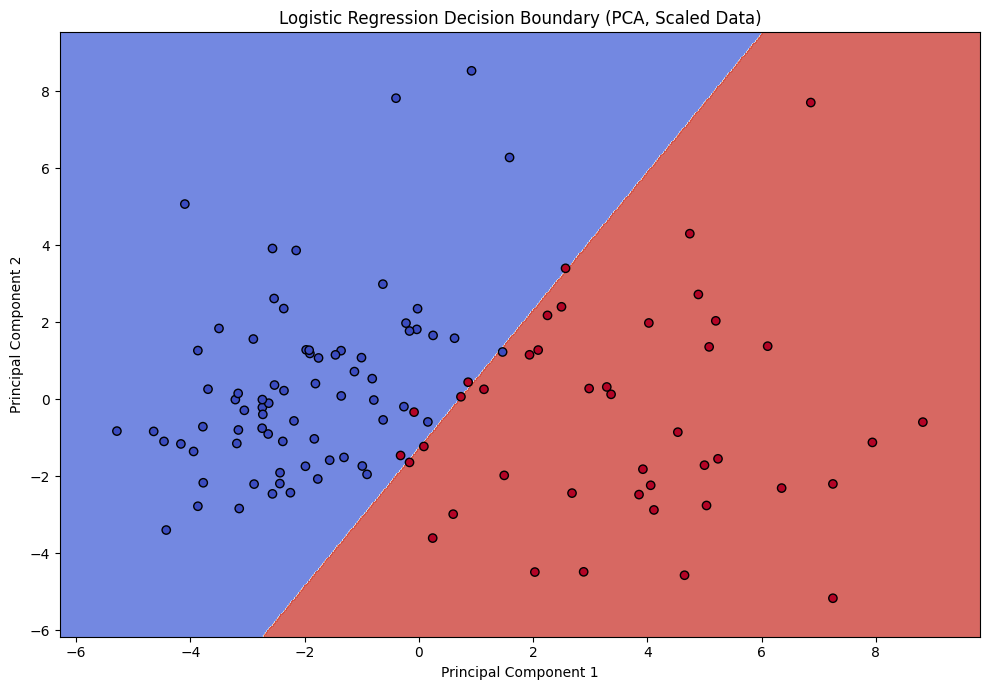

In [7]:
pca = PCA(n_components=2)
X_test_pca  = pca.fit_transform(X_test)

model_2d = LogisticRegression(max_iter=1000, random_state=42)
model_2d.fit(pca.transform(X_train), Y_train)

x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
            c=Y_test, edgecolors="k", cmap=plt.cm.coolwarm)
plt.title("Logistic Regression Decision Boundary (PCA, Scaled Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

## 3D PCA Scatter Plot

A 3D projection onto the top three principal components gives a richer view of the class separation in the feature space.

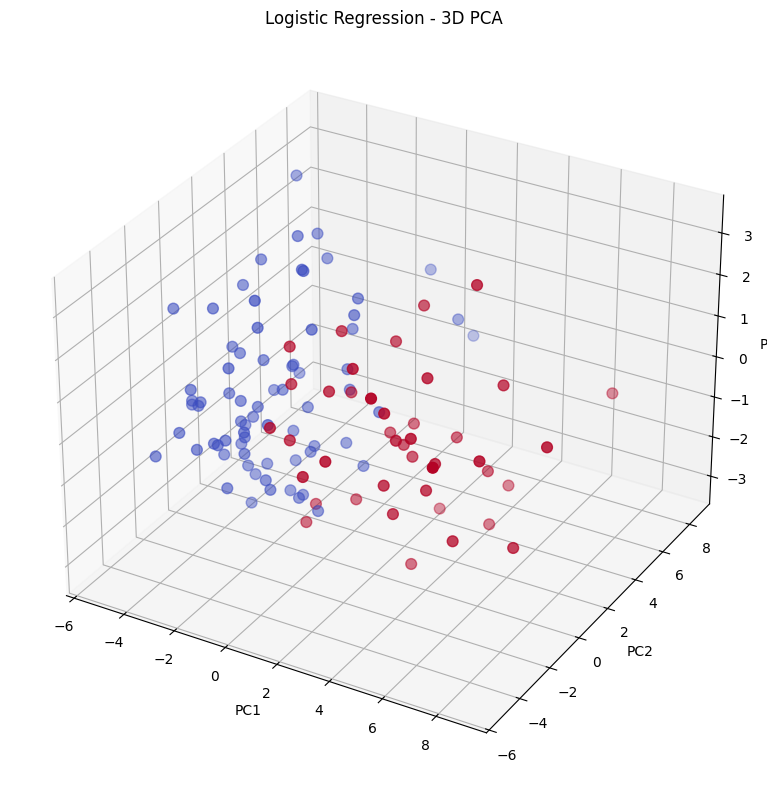

In [8]:
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_test)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=Y_test, cmap="coolwarm", s=60)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("Logistic Regression - 3D PCA")
plt.tight_layout()
plt.show()

In [9]:
import os, numpy as np

os.makedirs("../data/models", exist_ok=True)
np.savetxt("../data/models/lr_predictions.csv", predictions, delimiter=",", fmt="%d")
print("Saved lr_predictions.csv")

Saved lr_predictions.csv
